In [8]:
# Bayesian Optimization mit globalen Nullmodellen aus Ordner mit counter
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# =============================
# 1) Proximity-Funktion (Gaussian)
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2,   # wie viele Peaks links+rechts von x getestet werden
    norm_x=1.0,
    output_max=1.0
):
    """
    Optimierte Gaussian-Proximity-Funktion:
    - prüft nur die Ratio-Peaks, die in der Nähe von x liegen (k/f ± neighbor_peaks)
    - x: Skalar oder Array
    - Rückgabe: Array gleicher Form
    """
    x = np.array(x, dtype=float)
    all_freq_values = []

    for f in range(1, max_freq + 1):
        weight = 1.0 / (f ** weight_exponent)
        gauss_max = np.zeros_like(x, dtype=float)

        # nächstliegender Peak-Index zu jedem x
        k_center = np.round(x * f).astype(int)

        for offset in range(-neighbor_peaks, neighbor_peaks + 1):
            k = k_center + offset
            valid = k > 0  # negative oder 0 Peaks sind Unsinn

            if not np.any(valid):
                continue

            mu = k[valid] / f
            sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k[valid] ** sharpness_growth)
            sigma = 1.0 / (sharpness + 1e-9)
            mu_decay = 1.0 / (mu ** decay)

            # Broadcasting über alle validen Peaks
            g = np.exp(-0.5 * ((x[..., None] - mu[None, ...]) / sigma[None, ...]) ** 2)
            contrib = weight * mu_decay * g

            # Max über Peaks in Nachbarschaft
            gauss_max = np.maximum(gauss_max, np.max(contrib, axis=-1))

        all_freq_values.append(gauss_max)

    result = np.maximum.reduce(all_freq_values)

    # Normierung
    max_at_norm_x = np.max([
        (1.0 / (f ** weight_exponent))
        for f in range(1, max_freq + 1)
    ])
    return result / (max_at_norm_x + 1e-9) * output_max

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    # nur beim allerersten Funktionsaufruf ausgeben
    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
        # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}
    null_cache_empirical = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq_gaussian(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq_gaussian(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

        # Empirical Null (zieht zufällig IOIs aus ALLEN IOIs des Ordners)
        if n not in null_cache_empirical:
            medians_empirical = []
            for _ in range(num_sequences):
                sim_iois = rng.choice(all_iois, size=n, replace=True)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq_gaussian(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_empirical.append(np.median(prox_mat[triu_idx]))
            null_cache_empirical[n] = np.array(medians_empirical)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq_gaussian(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # Empirical
        medians_empirical = null_cache_empirical[n]
        mean_empirical = np.mean(medians_empirical)
        std_empirical = np.std(medians_empirical, ddof=1)
        zscore_empirical = (median_real - mean_empirical) / std_empirical if std_empirical > 0 else np.nan
        pval_empirical = (np.sum(medians_empirical >= median_real) + 1) / (len(medians_empirical) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "empirical_mean": mean_empirical,   
            "empirical_std": std_empirical,     
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "diff_real_empirical": median_real - mean_empirical,   
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "zscore_empirical": zscore_empirical,   
            "pval_empirical": pval_empirical        
        })


    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform", "empirical"
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params,
                                                num_sequences=num_sequences, seed=seed)

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)"

# Parameter für bayesian_search_global_null
n_calls = 60
num_sequences = 100
seed = 42
objective = "pval"   # Ziele: "diff", "zscore" oder "pval"
null_model = "empirical"   # Nullmodelle: "expon", "uniform", "empirical"
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search_global_null(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")

=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)
n_calls: 60
num_sequences: 100
seed: 42
objective: pval
null_model: empirical
[Bayesian Optimization] Iteration 1 / 60 (ETA: 0m 0s)
Global median IOI = 0.446
Uniform bounds = [0.388, 0.634]


KeyboardInterrupt: 

In [1]:
# Bayesian Optimization mit globalen Nullmodellen aus Ordner mit counter
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# =============================
# 1) Proximity-Funktion (Gaussian)
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    output_max=1.0,
    threshold=0.01,
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))
    N = len(x)
    result = np.zeros(N)
    best_frac = [(0, 0)] * N

    for f in range(1, max_freq + 1):
        k_vals = np.arange(f, x_max * f + 1)
        mu_all = k_vals / f
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        sigma_all = 1.0 / (sharpness_f * (k_vals ** sharpness_growth) + 1e-9)
        weight_f = 1.0 / (f ** weight_exponent)
        mu_decay_all = 1.0 / (mu_all ** decay)

        diff = x[:, None] - mu_all[None, :]
        g = weight_f * mu_decay_all[None, :] * np.exp(-0.5 * (diff / sigma_all[None, :])**2)
        best_idx = np.argmax(g, axis=1)
        best_val = g[np.arange(N), best_idx]
        update_idx = best_val > result
        result[update_idx] = best_val[update_idx]
        for idx in np.where(update_idx)[0]:
            best_frac[idx] = (int(k_vals[best_idx[idx]]), f)

    if result.max() > 0:
        result /= result.max()
    result *= output_max
    result[result < threshold] = threshold
    return result

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    # nur beim allerersten Funktionsaufruf ausgeben
    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
        # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}
    null_cache_empirical = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq_gaussian(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq_gaussian(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

        # Empirical Null (zieht zufällig IOIs aus ALLEN IOIs des Ordners)
        if n not in null_cache_empirical:
            medians_empirical = []
            for _ in range(num_sequences):
                sim_iois = rng.choice(all_iois, size=n, replace=True)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq_gaussian(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_empirical.append(np.median(prox_mat[triu_idx]))
            null_cache_empirical[n] = np.array(medians_empirical)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq_gaussian(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # Empirical
        medians_empirical = null_cache_empirical[n]
        mean_empirical = np.mean(medians_empirical)
        std_empirical = np.std(medians_empirical, ddof=1)
        zscore_empirical = (median_real - mean_empirical) / std_empirical if std_empirical > 0 else np.nan
        pval_empirical = (np.sum(medians_empirical >= median_real) + 1) / (len(medians_empirical) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "empirical_mean": mean_empirical,   
            "empirical_std": std_empirical,     
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "diff_real_empirical": median_real - mean_empirical,   
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "zscore_empirical": zscore_empirical,   
            "pval_empirical": pval_empirical        
        })


    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform", "empirical"
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params,
                                                num_sequences=num_sequences, seed=seed)

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)"

# Parameter für bayesian_search_global_null
n_calls = 60
num_sequences = 100
seed = 42
objective = "pval"   # Ziele: "diff", "zscore" oder "pval"
null_model = "empirical"   # Nullmodelle: "expon", "uniform", "empirical"
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search_global_null(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")

=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)
n_calls: 60
num_sequences: 100
seed: 42
objective: pval
null_model: empirical
[Bayesian Optimization] Iteration 1 / 60 (ETA: 0m 0s)
Global median IOI = 0.446
Uniform bounds = [0.388, 0.634]


TypeError: proximity_max_freq_gaussian() got an unexpected keyword argument 'norm_x'

In [20]:
# In dieser Version werden die Nullmodelle für jede Sequenzlänge n direkt
# neu simuliert und als Proximity-Matrizen zwischengespeichert.
# Für jede Kombination (n, Nullmodell) werden also num_sequences komplette
# IOI-Folgen erzeugt → Ratios berechnet → Proximity-Funktion angewendet →
# Medianwerte gespeichert.
#
# Vorteil:
# - Einfach und transparent: jeder Durchlauf erzeugt frische Nullsequenzen
#   für die jeweilige Analyse.
# Nachteil:
# - Speicherintensiv, da große Proximity-Matrizen im Cache gehalten werden.
# - Rechenaufwändig, da bei jeder neuen Parametrisierung der Proximity-Funktion
#   die Nullsequenzen erneut durch die Funktion laufen müssen.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# =============================
# Proximity-Funktion (Gaussian)
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2,
    norm_x=1.0,
    output_max=1.0
):
    """
    Schnellere, vektorisierte Version der Gaussian-Proximity-Funktion.
    - x: Skalar oder 1D-Array
    - Rückgabe: Array gleicher Form wie x
    """

    x = np.atleast_1d(x).astype(float)
    gauss_max = np.zeros_like(x)

    freqs = np.arange(1, max_freq + 1)

    # Schleife über Frequenzen (klein, meist max_freq <= 6)
    for f in freqs:
        weight = 1.0 / (f ** weight_exponent)

        # nächstliegender Peak für jedes x
        k_center = np.round(x * f).astype(int)

        # alle Nachbar-Peaks gleichzeitig
        offsets = np.arange(-neighbor_peaks, neighbor_peaks + 1)
        k_all = k_center[:, None] + offsets[None, :]  # Form: (len(x), 2*neighbor_peaks+1)
        valid_mask = k_all > 0
        k_all = k_all * valid_mask  # ungültige Peaks auf 0

        # Peak-Mittelwerte mu
        mu = k_all / f
        mu[~valid_mask] = 1.0  # ungültige Peaks auf 1 (wird später durch mask ignoriert)

        # Sharpness und Sigma
        sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k_all ** sharpness_growth)
        sharpness[~valid_mask] = 1e-9  # um division durch null zu vermeiden
        sigma = 1.0 / (sharpness + 1e-9)

        # Abklingfaktor
        mu_decay = np.where(valid_mask, 1.0 / (mu ** decay + 1e-9), 0.0)

        # Gaussian-Berechnung über alle Peaks gleichzeitig
        diff = x[:, None] - mu
        g = np.exp(-0.5 * (diff / sigma) ** 2) * mu_decay * weight

        # Max über alle Peaks
        gauss_max = np.maximum(gauss_max, np.max(g, axis=1))

    # Normierung
    max_at_norm_x = np.max([1.0 / (f ** weight_exponent) for f in freqs])
    gauss_max = gauss_max / (max_at_norm_x + 1e-9) * output_max

    # Rückgabe gleiche Form wie Input
    return gauss_max if gauss_max.shape != (1,) else gauss_max[0]

# ================================
# Folder-Analyse
# ================================

def pairwise_ratios(iois: np.ndarray) -> np.ndarray:
    """Vektorisierte Berechnung aller Ratio-Paare (immer >= 1)."""
    mat = np.divide.outer(iois, iois)
    return np.maximum(mat, 1 / mat)

_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True

    # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}
    null_cache_empirical = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = pairwise_ratios(sim_iois)
                triu_idx = np.triu_indices_from(ratios, k=1)
                prox_mat = proximity_max_freq_gaussian(ratios[triu_idx], **params)
                medians_expon.append(np.median(prox_mat))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = pairwise_ratios(sim_iois)
                triu_idx = np.triu_indices_from(ratios, k=1)
                prox_mat = proximity_max_freq_gaussian(ratios[triu_idx], **params)
                medians_uniform.append(np.median(prox_mat))
            null_cache_uniform[n] = np.array(medians_uniform)

        # Empirical Null
        if n not in null_cache_empirical:
            medians_empirical = []
            for _ in range(num_sequences):
                sim_iois = rng.choice(all_iois, size=n, replace=True)
                ratios = pairwise_ratios(sim_iois)
                triu_idx = np.triu_indices_from(ratios, k=1)
                prox_mat = proximity_max_freq_gaussian(ratios[triu_idx], **params)
                medians_empirical.append(np.median(prox_mat))
            null_cache_empirical[n] = np.array(medians_empirical)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = pairwise_ratios(iois)
        triu_idx = np.triu_indices_from(ratios, k=1)
        prox_mat_real = proximity_max_freq_gaussian(ratios[triu_idx], **params)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(prox_mat_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # Empirical
        medians_empirical = null_cache_empirical[n]
        mean_empirical = np.mean(medians_empirical)
        std_empirical = np.std(medians_empirical, ddof=1)
        zscore_empirical = (median_real - mean_empirical) / std_empirical if std_empirical > 0 else np.nan
        pval_empirical = (np.sum(medians_empirical >= median_real) + 1) / (len(medians_empirical) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "empirical_mean": mean_empirical,   
            "empirical_std": std_empirical,     
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "diff_real_empirical": median_real - mean_empirical,   
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "zscore_empirical": zscore_empirical,   
            "pval_empirical": pval_empirical        
        })

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform", "empirical"
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"neighbor_peaks": 2, "norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params,
                                                num_sequences=num_sequences, seed=seed)

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Sequenz-Werte
# ================================

def optimize_and_collect(folders, n_calls=30, num_sequences=50, seed=42, objective="pval"):
    all_seq_results = []

    for folder in folders:
        for null_model in ["expon", "uniform", "empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")

            # 1. Bayesian Optimization laufen lassen
            summary_eval_df, best_row, res = bayesian_search_global_null(
                folder_path=folder,
                n_calls=n_calls,
                num_sequences=num_sequences,
                seed=seed,
                objective=objective,
                null_model=null_model
            )

            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue

            # 2. Beste Parameter extrahieren
            param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
            best_params = {col: best_row[col] for col in param_cols}
            best_params.update({"norm_x":1.0, "output_max":1.0})

            print("Beste Parameterkombination:")
            print(best_params)

            # 3. Sequenzen mit besten Parametern analysieren
            df_seq = analyze_folder_global_null(
                folder_path=folder,
                params=best_params,
                num_sequences=num_sequences,
                seed=seed
            )

            if df_seq.empty:
                continue

            # 4. Werte pro Sequenz speichern
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                # gefundene Parameter mit aufnehmen
                for p in param_cols:
                    record[p] = best_params[p]
                all_seq_results.append(record)

    return pd.DataFrame(all_seq_results)

# ================================
# Boxplots zeichnen
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_uniform",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/isochron jitter different tempo"
    ]

seq_results_df = optimize_and_collect(folders, n_calls=50, num_sequences=200, seed=42, objective="pval")

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("gaussian_optimization.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.")

Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon, Nullmodell=expon, Objective=pval
[Bayesian Optimization] Iteration 1 / 50 (ETA: 0m 0s)
Global median IOI = 0.275
Uniform bounds = [0.100, 1.242]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [14]:
# In dieser Version werden die Nullmodelle effizienter gecacht:
# Anstatt komplette Proximity-Matrizen zu speichern, werden nur die rohen
# IOI-Ratios der Nullsequenzen im Cache abgelegt (pro Sequenzlänge n und Modell).
# Bei jeder neuen Parametrisierung der Proximity-Funktion werden diese Ratios
# erneut durch proximity_max_freq_gaussian geschickt und ausgewertet.
#
# Vorteil:
# - Deutlich speicherschonender: es müssen keine Matrizen von Proximity-Werten
#   vorgehalten werden, nur Ratios (viel kleiner).
# - Flexibel: die gleichen Nullsequenzen können mehrfach für verschiedene
#   Parameterkombinationen wiederverwendet werden.
# - Option null_resample=True erlaubt, zufällige Subsets aus dem Cache
#   neu auszuwählen, um Variation einzubauen.
# Nachteil:
# - Etwas höhere Rechenzeit pro Iteration (da Ratios immer wieder neu
#   durch die Proximity-Funktion laufen), aber insgesamt oft schneller,
#   weil das Caching kleiner und flexibler ist.


import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ================================
# Proximity-Funktion
# ================================

def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2,   # wie viele Peaks links+rechts von x getestet werden
    norm_x=1.0,
    output_max=1.0
):
    """
    Optimierte Gaussian-Proximity-Funktion:
    - prüft nur die Ratio-Peaks, die in der Nähe von x liegen (k/f ± neighbor_peaks)
    - x: Skalar oder Array
    - Rückgabe: Array gleicher Form
    """
    x = np.array(x, dtype=float)
    all_freq_values = []

    for f in range(1, max_freq + 1):
        weight = 1.0 / (f ** weight_exponent)
        gauss_max = np.zeros_like(x, dtype=float)

        # nächstliegender Peak-Index zu jedem x
        k_center = np.round(x * f).astype(int)

        for offset in range(-neighbor_peaks, neighbor_peaks + 1):
            k = k_center + offset
            valid = k > 0  # negative oder 0 Peaks sind Unsinn

            if not np.any(valid):
                continue

            mu = k[valid] / f
            sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k[valid] ** sharpness_growth)
            sigma = 1.0 / (sharpness + 1e-9)
            mu_decay = 1.0 / (mu ** decay)

            # Broadcasting über alle validen Peaks
            g = np.exp(-0.5 * ((x[..., None] - mu[None, ...]) / sigma[None, ...]) ** 2)
            contrib = weight * mu_decay * g

            # Max über Peaks in Nachbarschaft
            gauss_max = np.maximum(gauss_max, np.max(contrib, axis=-1))

        all_freq_values.append(gauss_max)

    result = np.maximum.reduce(all_freq_values)

    # Normierung
    max_at_norm_x = np.max([
        (1.0 / (f ** weight_exponent))
        for f in range(1, max_freq + 1)
    ])
    return result / (max_at_norm_x + 1e-9) * output_max

# ================================
# Folder-Analyse mit flexiblem Nullmodell-Caching (jetzt mit rohen Ratios)
# ================================
_already_printed_global_ioi = False

# Cache speichert rohe IOI-Ratios pro (n, model)
_null_cache_store = {"expon": {}, "uniform": {}, "empirical": {}}

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42,
                               null_resample=False, null_cache_size=5000):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True

    # -----------------------------
    # 2) Nullmodelle vorbereiten (nur rohe IOI-Ratios cachen!)
    # -----------------------------
    def build_null_ratios(n, model):
        ratios_list = []
        for _ in range(null_cache_size):
            if model == "expon":
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
            elif model == "uniform":
                sim_iois = rng.uniform(global_min, global_max, size=n)
            elif model == "empirical":
                sim_iois = rng.choice(all_iois, size=n, replace=True)
            # Ratios berechnen und speichern
            ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                for j in range(n)] for i in range(n)])
            ratios_list.append(ratios)
        return ratios_list

    # Falls nicht vorhanden: neue Nullratios in Cache speichern
    for fname, iois in seqs:
        n = len(iois)
        for model in ["expon", "uniform", "empirical"]:
            if n not in _null_cache_store[model]:
                _null_cache_store[model][n] = build_null_ratios(n, model)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        # Realwerte
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq_gaussian(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        median_real = np.median(prox_mat_real[triu_idx])

        out = {"filename": fname, "real_median": median_real}

        for model in ["expon", "uniform", "empirical"]:
            all_ratios = _null_cache_store[model][n]
            if null_resample:
                chosen = rng.choice(len(all_ratios), size=num_sequences, replace=False)
            else:
                chosen = range(min(num_sequences, len(all_ratios)))
            medians = []
            for idx in chosen:
                prox_mat_null = proximity_max_freq_gaussian(all_ratios[idx], **params)
                triu_idx = np.triu_indices_from(prox_mat_null, k=1)
                medians.append(np.median(prox_mat_null[triu_idx]))
            medians = np.array(medians)

            mean_val = np.mean(medians)
            std_val = np.std(medians, ddof=1)
            zscore_val = (median_real - mean_val) / std_val if std_val > 0 else np.nan
            pval_val = (np.sum(medians >= median_real) + 1) / (len(medians) + 1)

            out.update({
                f"{model}_mean": mean_val,
                f"{model}_std": std_val,
                f"diff_real_{model}": median_real - mean_val,
                f"zscore_{model}": zscore_val,
                f"pval_{model}": pval_val
            })

        results_list.append(out)

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # "expon", "uniform", "empirical"
    param_space_def=None,
    null_resample=False,        # <--- HIER hinzufügen
    null_cache_size=5000        # <--- HIER hinzufügen
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"neighbor_peaks": 2, "norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(
            folder_path,
            params,
            num_sequences=num_sequences,
            seed=seed,
            null_resample=null_resample,
            null_cache_size=null_cache_size 
        )

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Sequenz-Werte
# ================================

def optimize_and_collect(folders, n_calls=30, num_sequences=50, seed=42, 
                         objective="pval", null_resample=False, null_cache_size=5000
    ):
    all_seq_results = []

    for folder in folders:
        for null_model in ["expon", "uniform", "empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")

            # 1. Bayesian Optimization laufen lassen
            summary_eval_df, best_row, res = bayesian_search_global_null(
                folder_path=folder,
                n_calls=n_calls,
                num_sequences=num_sequences,
                seed=seed,
                objective=objective,
                null_model=null_model,
                null_resample=null_resample, 
                null_cache_size=null_cache_size
            )

            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue

            # 2. Beste Parameter extrahieren
            param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
            best_params = {col: best_row[col] for col in param_cols}
            best_params.update({"norm_x":1.0, "output_max":1.0})

            print("Beste Parameterkombination:")
            print(best_params)

            # 3. Sequenzen mit besten Parametern analysieren
            df_seq = analyze_folder_global_null(
                folder_path=folder,
                params=best_params,
                num_sequences=num_sequences,
                seed=seed
            )

            if df_seq.empty:
                continue

            # 4. Werte pro Sequenz speichern
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                # gefundene Parameter mit aufnehmen
                for p in param_cols:
                    record[p] = best_params[p]
                all_seq_results.append(record)

    return pd.DataFrame(all_seq_results)

# ================================
# Boxplots zeichnen
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_uniform",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/isochron jitter different tempo",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/kwa sounds",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/tempo shift no jitter",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/heterochrony-2-3_0050-jitter"
]

seq_results_df = optimize_and_collect(folders, n_calls=30, num_sequences=100, seed=42, objective="pval", null_resample=False, null_cache_size=1000)

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("seq_level_results.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'seq_level_results.csv' gespeichert.")


Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon, Nullmodell=expon, Objective=pval
[Bayesian Optimization] Iteration 1 / 30 (ETA: 0m 0s)
Global median IOI = 0.275
Uniform bounds = [0.100, 1.242]
[Bayesian Optimization] Iteration 2 / 30 (ETA: 33m 54s)
[Bayesian Optimization] Iteration 3 / 30 (ETA: 37m 38s)
[Bayesian Optimization] Iteration 4 / 30 (ETA: 41m 12s)
[Bayesian Optimization] Iteration 5 / 30 (ETA: 34m 39s)
[Bayesian Optimization] Iteration 6 / 30 (ETA: 41m 13s)
[Bayesian Optimization] Iteration 7 / 30 (ETA: 45m 21s)
[Bayesian Optimization] Iteration 8 / 30 (ETA: 44m 54s)
[Bayesian Optimization] Iteration 9 / 30 (ETA: 44m 43s)
[Bayesian Optimization] Iteration 10 / 30 (ETA: 42m 3s)
[Bayesian Optimization] Iteration 11 / 30 (ETA: 40m 10s)


KeyboardInterrupt: 

In [15]:
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import time

# ==========================================================
# Vektorisierte Proximity-Funktion (unverändert, aber effizient nutzbar)
# ==========================================================

def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2,   # wie viele Peaks links+rechts von x getestet werden
    norm_x=1.0,
    output_max=1.0
):
    """
    Optimierte Gaussian-Proximity-Funktion:
    - prüft nur die Ratio-Peaks, die in der Nähe von x liegen (k/f ± neighbor_peaks)
    - x: Skalar oder Array
    - Rückgabe: Array gleicher Form
    """
    x = np.array(x, dtype=float)
    all_freq_values = []

    for f in range(1, max_freq + 1):
        weight = 1.0 / (f ** weight_exponent)
        gauss_max = np.zeros_like(x, dtype=float)

        # nächstliegender Peak-Index zu jedem x
        k_center = np.round(x * f).astype(int)

        for offset in range(-neighbor_peaks, neighbor_peaks + 1):
            k = k_center + offset
            valid = k > 0  # negative oder 0 Peaks sind Unsinn

            if not np.any(valid):
                continue

            mu = k[valid] / f
            sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k[valid] ** sharpness_growth)
            sigma = 1.0 / (sharpness + 1e-9)
            mu_decay = 1.0 / (mu ** decay)

            # Broadcasting über alle validen Peaks
            g = np.exp(-0.5 * ((x[..., None] - mu[None, ...]) / sigma[None, ...]) ** 2)
            contrib = weight * mu_decay * g

            # Max über Peaks in Nachbarschaft
            gauss_max = np.maximum(gauss_max, np.max(contrib, axis=-1))

        all_freq_values.append(gauss_max)

    result = np.maximum.reduce(all_freq_values)

    # Normierung
    max_at_norm_x = np.max([
        (1.0 / (f ** weight_exponent))
        for f in range(1, max_freq + 1)
    ])
    return result / (max_at_norm_x + 1e-9) * output_max

# ==========================================================
# Schneller Nullmodell-Cache: speichert nur flache Ratios (triu)
# ==========================================================
_null_cache_store = {"expon": {}, "uniform": {}, "empirical": {}}

def build_null_ratios(n, model, rng, global_median_ioi, global_min, global_max, all_iois, null_cache_size):
    ratios_list = []
    triu_idx = np.triu_indices(n, k=1)
    for _ in range(null_cache_size):
        if model == "expon":
            sim_iois = rng.exponential(scale=global_median_ioi, size=n)
        elif model == "uniform":
            sim_iois = rng.uniform(global_min, global_max, size=n)
        elif model == "empirical":
            sim_iois = rng.choice(all_iois, size=n, replace=True)
        ratios = np.maximum(sim_iois[:, None], sim_iois[None, :]) / np.minimum(sim_iois[:, None], sim_iois[None, :])
        ratios_list.append(ratios[triu_idx])  # nur obere Dreiecksmatrix speichern
    return np.array(ratios_list)

# ==========================================================
# Analyse mit schnellem Zugriff auf Cache
# ==========================================================

def analyze_folder_global_null_fast(folder_path, params, num_sequences=500, seed=42, null_resample=False, null_cache_size=2000):
    rng = np.random.default_rng(seed)
    results_list = []

    # IOIs laden
    all_iois = []
    seqs = []
    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue
        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue
        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    for fname, iois in seqs:
        n = len(iois)
        triu_idx = np.triu_indices(n, k=1)

        # reale Ratios
        ratios_real = np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :])
        prox_vals_real = proximity_max_freq_gaussian(ratios_real, **params)[triu_idx]
        median_real = np.median(prox_vals_real)

        out = {"filename": fname, "real_median": median_real}

        # Nullmodelle
        for model in ["expon", "uniform", "empirical"]:
            if n not in _null_cache_store[model]:
                _null_cache_store[model][n] = build_null_ratios(n, model, rng, global_median_ioi, global_min, global_max, all_iois, null_cache_size)

            all_ratios_flat = _null_cache_store[model][n]
            if null_resample:
                chosen = rng.choice(len(all_ratios_flat), size=num_sequences, replace=False)
            else:
                chosen = range(min(num_sequences, len(all_ratios_flat)))

            # gleichzeitig Proximity berechnen (Vektorisierung)
            prox_vals = proximity_max_freq_gaussian(all_ratios_flat[chosen], **params)
            medians = np.median(prox_vals, axis=1)

            mean_val = np.mean(medians)
            std_val = np.std(medians, ddof=1)
            zscore_val = (median_real - mean_val) / std_val if std_val > 0 else np.nan
            pval_val = (np.sum(medians >= median_real) + 1) / (len(medians) + 1)

            out.update({
                f"{model}_mean": mean_val,
                f"{model}_std": std_val,
                f"diff_real_{model}": median_real - mean_val,
                f"zscore_{model}": zscore_val,
                f"pval_{model}": pval_val
            })

        results_list.append(out)

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # "expon", "uniform", "empirical"
    param_space_def=None,
    null_resample=False,        # <--- HIER hinzufügen
    null_cache_size=5000        # <--- HIER hinzufügen
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"neighbor_peaks": 2, "norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(
            folder_path,
            params,
            num_sequences=num_sequences,
            seed=seed,
            null_resample=null_resample,
            null_cache_size=null_cache_size 
        )

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Sequenz-Werte
# ================================

def optimize_and_collect(folders, n_calls=30, num_sequences=50, seed=42, 
                         objective="pval", null_resample=False, null_cache_size=5000
    ):
    all_seq_results = []

    for folder in folders:
        for null_model in ["expon", "uniform", "empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")

            # 1. Bayesian Optimization laufen lassen
            summary_eval_df, best_row, res = bayesian_search_global_null(
                folder_path=folder,
                n_calls=n_calls,
                num_sequences=num_sequences,
                seed=seed,
                objective=objective,
                null_model=null_model,
                null_resample=null_resample, 
                null_cache_size=null_cache_size
            )

            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue

            # 2. Beste Parameter extrahieren
            param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
            best_params = {col: best_row[col] for col in param_cols}
            best_params.update({"norm_x":1.0, "output_max":1.0})

            print("Beste Parameterkombination:")
            print(best_params)

            # 3. Sequenzen mit besten Parametern analysieren
            df_seq = analyze_folder_global_null_fast(
                folder_path=folder,
                params=best_params,
                num_sequences=num_sequences,
                seed=seed
            )

            if df_seq.empty:
                continue

            # 4. Werte pro Sequenz speichern
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                # gefundene Parameter mit aufnehmen
                for p in param_cols:
                    record[p] = best_params[p]
                all_seq_results.append(record)

    return pd.DataFrame(all_seq_results)

# ================================
# Boxplots zeichnen
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_uniform",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/isochron jitter different tempo",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/kwa sounds",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/tempo shift no jitter",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/heterochrony-2-3_0050-jitter"
]

seq_results_df = optimize_and_collect(folders, n_calls=30, num_sequences=100, seed=42, objective="pval", null_resample=False, null_cache_size=1000)

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("seq_level_results.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'seq_level_results.csv' gespeichert.")


Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon, Nullmodell=expon, Objective=pval
[Bayesian Optimization] Iteration 1 / 30 (ETA: 0m 0s)


KeyboardInterrupt: 

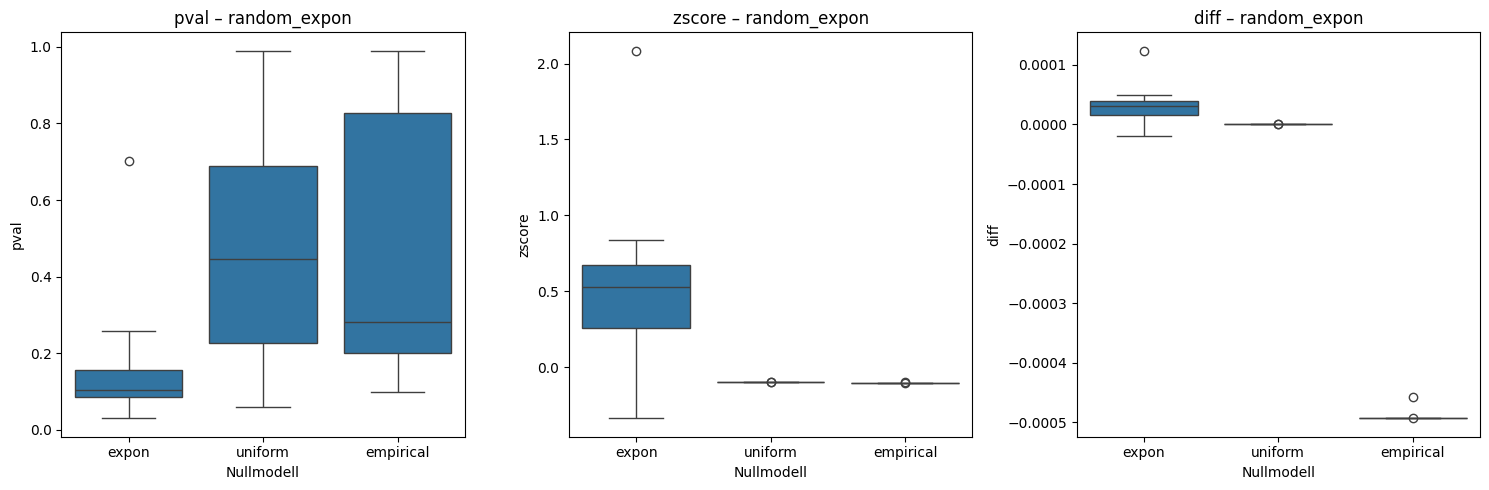

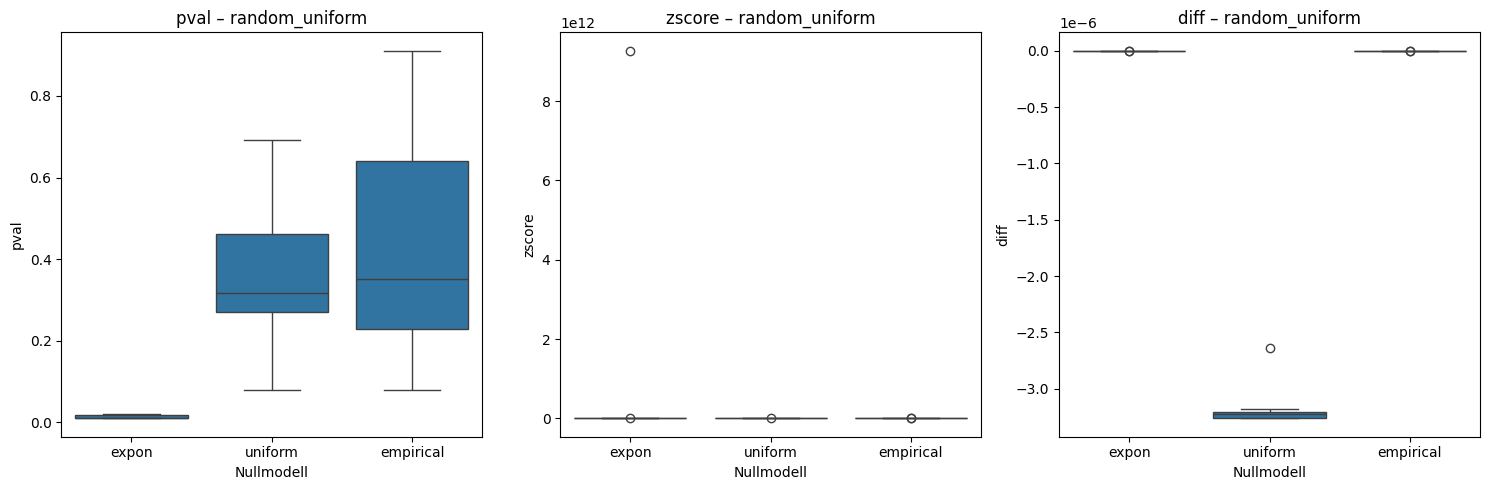

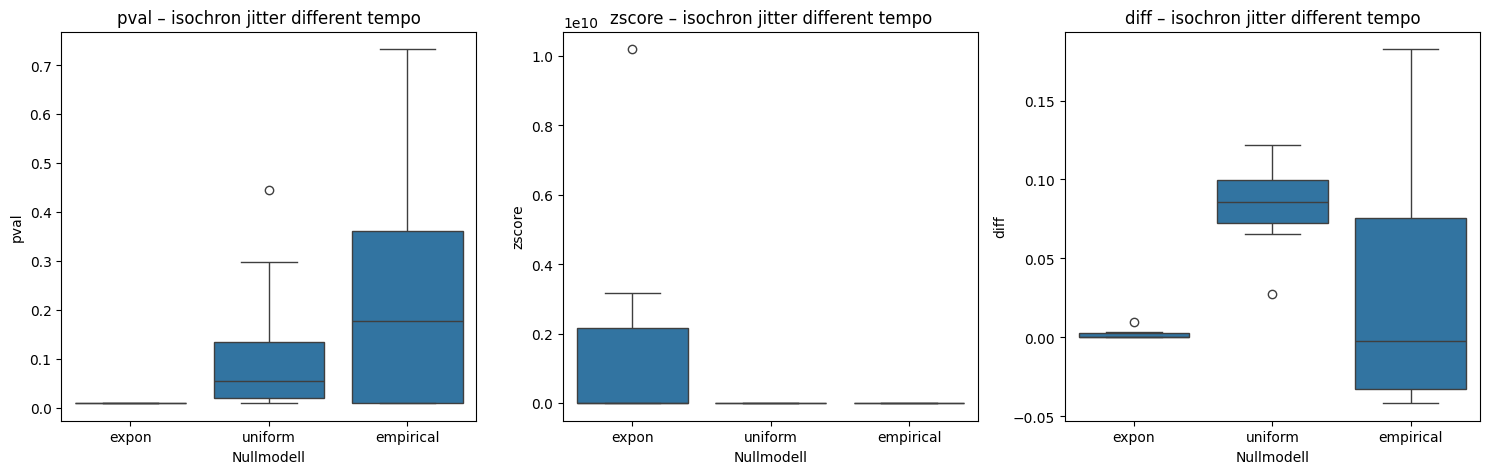

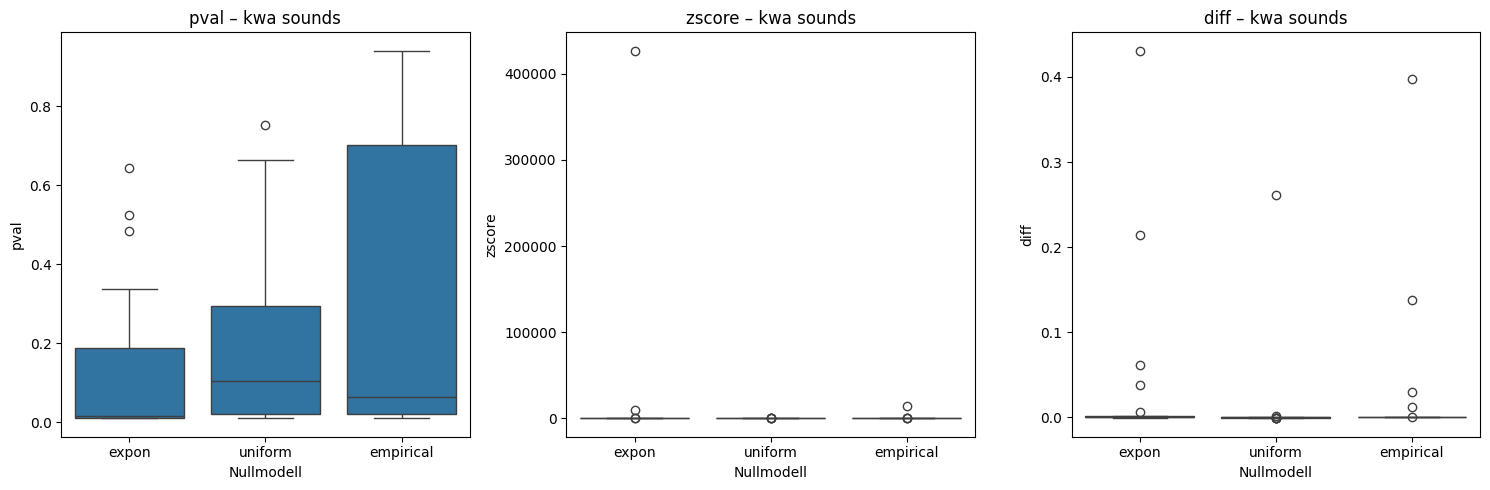

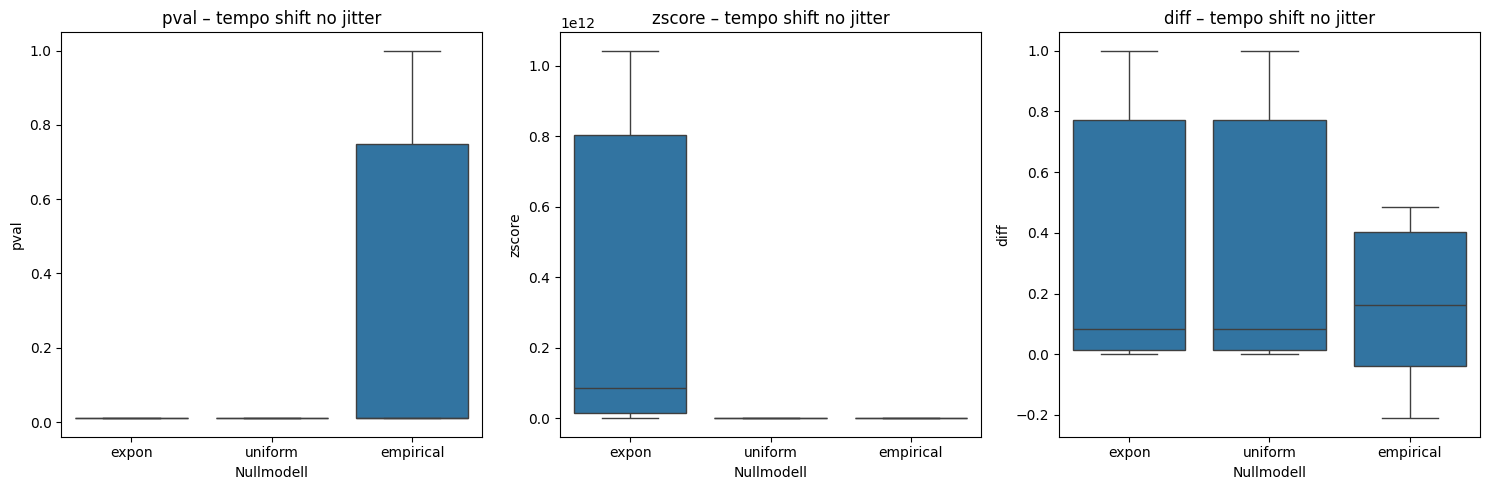

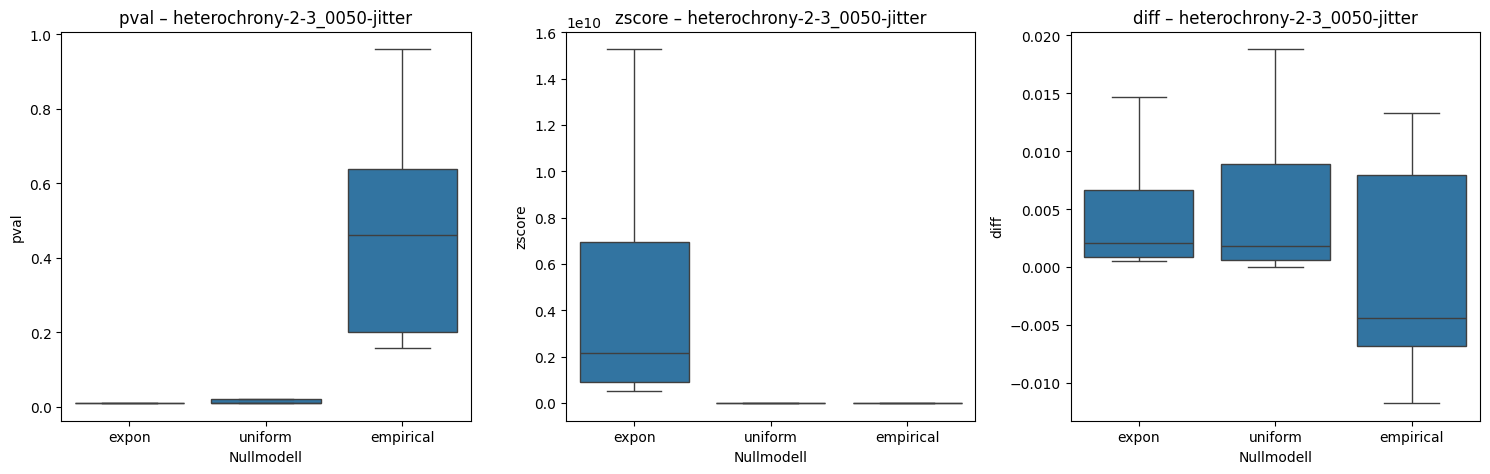

Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.


In [7]:
def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

seq_results_df = pd.read_csv("/Users/emilschmiedl/Desktop/Proximity-Funktion/code/gaussian_optimization.csv")

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    print("Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.")


Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon, Nullmodell=expon, Objective=pval
[Bayesian Optimization] Iteration 1 / 50 (ETA: 0m 0s)
Global median IOI = 0.275
Uniform bounds = [0.100, 1.242]
[Bayesian Optimization] Iteration 2 / 50 (ETA: 0m 22s)
[Bayesian Optimization] Iteration 3 / 50 (ETA: 0m 27s)
[Bayesian Optimization] Iteration 4 / 50 (ETA: 0m 32s)
[Bayesian Optimization] Iteration 5 / 50 (ETA: 0m 28s)
[Bayesian Optimization] Iteration 6 / 50 (ETA: 0m 28s)
[Bayesian Optimization] Iteration 7 / 50 (ETA: 0m 30s)
[Bayesian Optimization] Iteration 8 / 50 (ETA: 0m 29s)
[Bayesian Optimization] Iteration 9 / 50 (ETA: 0m 28s)
[Bayesian Optimization] Iteration 10 / 50 (ETA: 0m 27s)
[Bayesian Optimization] Iteration 11 / 50 (ETA: 0m 30s)
[Bayesian Optimization] Iteration 12 / 50 (ETA: 0m 30s)
[Bayesian Optimization] Iteration 13 / 50 (ETA: 0m 31s)
[Bayesian Optimization] Iteration 14 / 50 (ETA: 0m 31s)
[Bayesian Optimization]

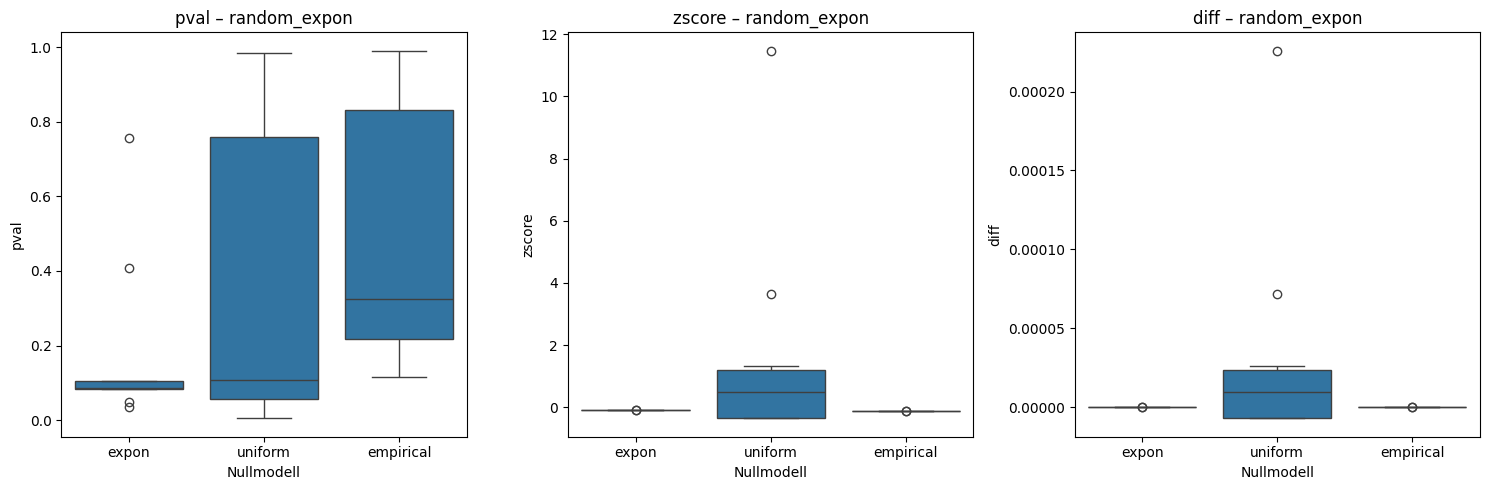

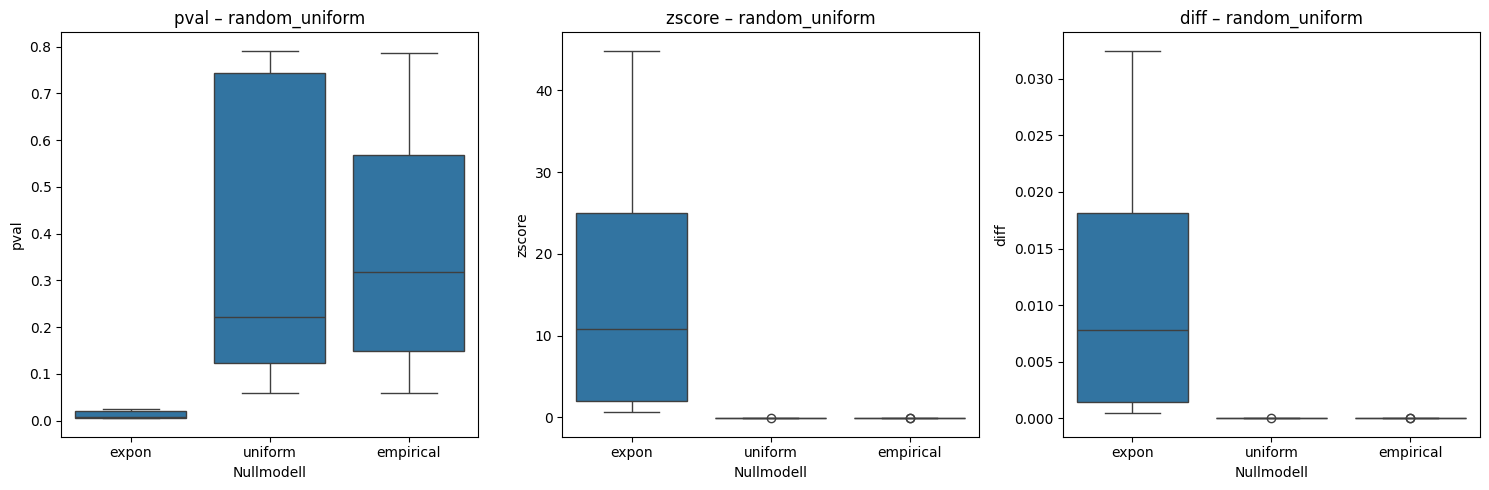

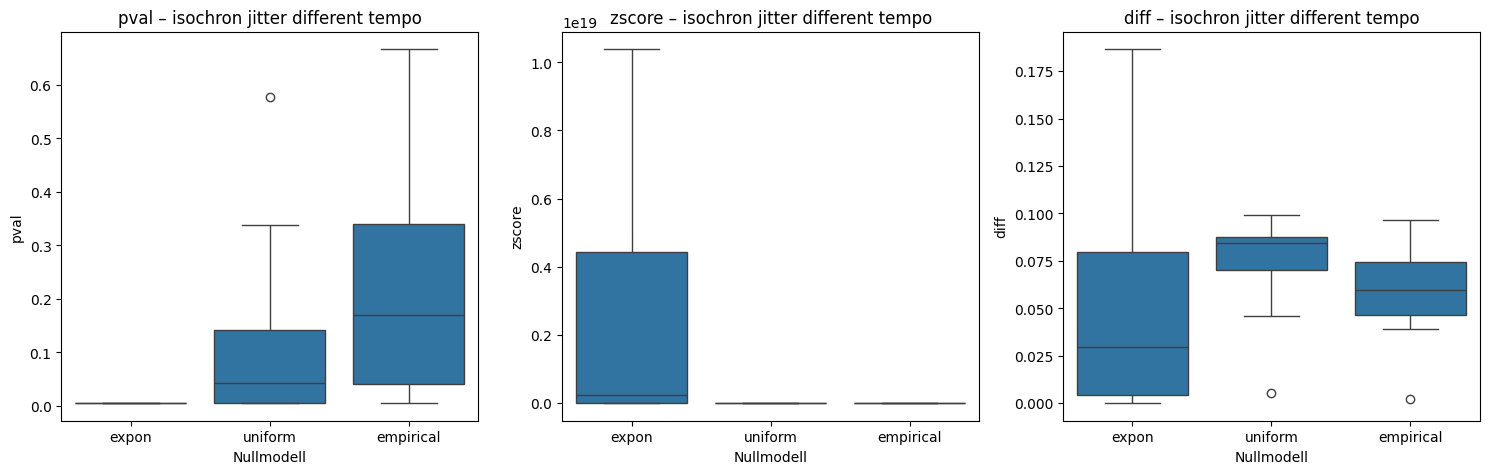

Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.


In [21]:
# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# =============================
# Proximity-Funktion (Gaussian)
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2,
    norm_x=1.0,
    output_max=1.0
):
    x = np.atleast_1d(x).astype(float)
    gauss_max = np.zeros_like(x)
    freqs = np.arange(1, max_freq + 1)

    for f in freqs:
        weight = 1.0 / (f ** weight_exponent)
        k_center = np.round(x * f).astype(int)
        offsets = np.arange(-neighbor_peaks, neighbor_peaks + 1)
        k_all = k_center[:, None] + offsets[None, :]
        valid_mask = k_all > 0
        k_all = k_all * valid_mask

        mu = k_all / f
        mu[~valid_mask] = 1.0

        sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k_all ** sharpness_growth)
        sharpness[~valid_mask] = 1e-9
        sigma = 1.0 / (sharpness + 1e-9)

        mu_decay = np.where(valid_mask, 1.0 / (mu ** decay + 1e-9), 0.0)
        diff = x[:, None] - mu
        g = np.exp(-0.5 * (diff / sigma) ** 2) * mu_decay * weight
        gauss_max = np.maximum(gauss_max, np.max(g, axis=1))

    max_at_norm_x = np.max([1.0 / (f ** weight_exponent) for f in freqs])
    gauss_max = gauss_max / (max_at_norm_x + 1e-9) * output_max
    return gauss_max if gauss_max.shape != (1,) else gauss_max[0]

# ================================
# Pairwise Ratios
# ================================
def pairwise_ratios(iois: np.ndarray) -> np.ndarray:
    mat = np.divide.outer(iois, iois)
    return np.maximum(mat, 1 / mat)

# ================================
# Folder-Analyse mit globalen Nullmodellen
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue
        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue
        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True

    # Nullmodelle zwischenspeichern
    null_cache_expon = {}
    null_cache_uniform = {}
    null_cache_empirical = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = pairwise_ratios(sim_iois)
                triu_idx = np.triu_indices_from(ratios, k=1)
                prox_mat = proximity_max_freq_gaussian(ratios[triu_idx], **params)
                medians_expon.append(np.median(prox_mat))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = pairwise_ratios(sim_iois)
                triu_idx = np.triu_indices_from(ratios, k=1)
                prox_mat = proximity_max_freq_gaussian(ratios[triu_idx], **params)
                medians_uniform.append(np.median(prox_mat))
            null_cache_uniform[n] = np.array(medians_uniform)

        # Empirical Null
        if n not in null_cache_empirical:
            medians_empirical = []
            for _ in range(num_sequences):
                sim_iois = rng.choice(all_iois, size=n, replace=True)
                ratios = pairwise_ratios(sim_iois)
                triu_idx = np.triu_indices_from(ratios, k=1)
                prox_mat = proximity_max_freq_gaussian(ratios[triu_idx], **params)
                medians_empirical.append(np.median(prox_mat))
            null_cache_empirical[n] = np.array(medians_empirical)

    # Analyse jeder Sequenz
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = pairwise_ratios(iois)
        triu_idx = np.triu_indices_from(ratios_real, k=1)
        prox_mat_real = proximity_max_freq_gaussian(ratios_real[triu_idx], **params)
        median_real = np.median(prox_mat_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # Empirical
        medians_empirical = null_cache_empirical[n]
        mean_empirical = np.mean(medians_empirical)
        std_empirical = np.std(medians_empirical, ddof=1)
        zscore_empirical = (median_real - mean_empirical) / std_empirical if std_empirical > 0 else np.nan
        pval_empirical = (np.sum(medians_empirical >= median_real) + 1) / (len(medians_empirical) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "empirical_mean": mean_empirical,   
            "empirical_std": std_empirical,     
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "diff_real_empirical": median_real - mean_empirical,   
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "zscore_empirical": zscore_empirical,   
            "pval_empirical": pval_empirical        
        })

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================
def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",
    null_model="expon",
    param_space_def=None
):
    rng = np.random.default_rng(seed)
    default_params = {"neighbor_peaks": 2, "norm_x": 1.0, "output_max": 1.0}

    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    sk_space = [
        Real(*param_space_def["sharpness_base"], name="sharpness_base"),
        Real(*param_space_def["sharpness_growth"], name="sharpness_growth"),
        Real(*param_space_def["decay"], name="decay"),
        Integer(*param_space_def["max_freq"], name="max_freq"),
        Real(*param_space_def["weight_exponent"], name="weight_exponent"),
        Real(*param_space_def["freq_sharpness_exp"], name="freq_sharpness_exp")
    ]

    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    def objective_func(x):
        call_counter["n"] += 1
        if timing_info["start"] is None:
            timing_info["start"] = time.time()
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
              f"(ETA: {eta_min}m {eta_sec}s)")

        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                 "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        results_df = analyze_folder_global_null(folder_path, params,
                                                num_sequences=num_sequences, seed=seed)
        if results_df.empty:
            return 1e6

        col_map = {"diff": f"diff_real_{null_model}",
                   "zscore": f"zscore_{null_model}",
                   "pval": f"pval_{null_model}"}
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})
        return score

    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)
    summary_eval_df = pd.DataFrame(eval_records)
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        best_idx = summary_eval_df[agg_col_name].idxmax() if objective in ("diff","zscore") else summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Sequenz-Werte
# ================================
def optimize_and_collect(folders, n_calls=30, num_sequences=50, seed=42, objective="pval"):
    all_seq_results = []
    for folder in folders:
        for null_model in ["expon", "uniform", "empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")
            summary_eval_df, best_row, res = bayesian_search_global_null(
                folder_path=folder,
                n_calls=n_calls,
                num_sequences=num_sequences,
                seed=seed,
                objective=objective,
                null_model=null_model
            )
            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue

            param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
            best_params = {col: best_row[col] for col in param_cols}
            best_params.update({"norm_x":1.0, "output_max":1.0})
            print("Beste Parameterkombination:")
            print(best_params)

            # 3. Sequenzen mit besten Parametern analysieren
            df_seq = analyze_folder_global_null(
                folder_path=folder,
                params=best_params,
                num_sequences=num_sequences,
                seed=seed
            )

            if df_seq.empty:
                continue

            # 4. Werte pro Sequenz speichern
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                # gefundene Parameter mit aufnehmen
                for p in param_cols:
                    record[p] = best_params[p]
                all_seq_results.append(record)

    return pd.DataFrame(all_seq_results)

# ================================
# Boxplots zeichnen
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_uniform",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/isochron jitter different tempo"
    ]

seq_results_df = optimize_and_collect(folders, n_calls=50, num_sequences=200, seed=42, objective="pval")

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("gaussian_optimization.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.")

Folder '/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon' geladen, 100 Sequenzen, Null-Pool erstellt.
Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon, Nullmodell=expon, Objective=pval
[BayesOpt] Iteration 1/30 (ETA 0m 3s)
[BayesOpt] Iteration 2/30 (ETA 12m 15s)
[BayesOpt] Iteration 3/30 (ETA 14m 17s)
[BayesOpt] Iteration 4/30 (ETA 15m 16s)
[BayesOpt] Iteration 5/30 (ETA 12m 46s)
[BayesOpt] Iteration 6/30 (ETA 13m 33s)
[BayesOpt] Iteration 7/30 (ETA 13m 54s)
[BayesOpt] Iteration 8/30 (ETA 13m 16s)
[BayesOpt] Iteration 9/30 (ETA 12m 55s)
[BayesOpt] Iteration 10/30 (ETA 12m 0s)
[BayesOpt] Iteration 11/30 (ETA 11m 31s)
[BayesOpt] Iteration 12/30 (ETA 10m 53s)
[BayesOpt] Iteration 13/30 (ETA 10m 34s)
[BayesOpt] Iteration 14/30 (ETA 9m 28s)
[BayesOpt] Iteration 15/30 (ETA 9m 7s)
[BayesOpt] Iteration 16/30 (ETA 8m 29s)
[BayesOpt] Iteration 17/30 (ETA 7m 51s)
[BayesOpt] Iteration 18/30 (ETA 7m 15s

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [50.0, 0.0, 0.0, np.int64(1), 0.0, 4.0] before, using random point [5.384998107815449, 3.7255020632700804, 1.460879444365047, np.int64(5), 1.3872564168843164, 2.600116500610746]
  warnings.warn(


[BayesOpt] Iteration 27/30 (ETA 1m 33s)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [50.0, 0.0, 0.0, np.int64(1), 0.0, 4.0] before, using random point [2.7251372811361074, 0.35563983129281945, 3.9674279311197305, np.int64(4), 2.209452709541023, 2.579691152157579]
  warnings.warn(


[BayesOpt] Iteration 28/30 (ETA 1m 3s)
[BayesOpt] Iteration 29/30 (ETA 0m 31s)
[BayesOpt] Iteration 30/30 (ETA 0m 0s)
Beste Parameterkombination: {'sharpness_base': np.float64(50.0), 'sharpness_growth': np.float64(5.0), 'decay': np.float64(1.033129214058129), 'max_freq': np.float64(6.0), 'weight_exponent': np.float64(0.7173947365897922), 'freq_sharpness_exp': np.float64(0.0), 'neighbor_peaks': 2, 'norm_x': 1.0, 'output_max': 1.0}
Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon, Nullmodell=empirical, Objective=pval
[BayesOpt] Iteration 1/30 (ETA 0m 0s)
[BayesOpt] Iteration 2/30 (ETA 7m 59s)
[BayesOpt] Iteration 3/30 (ETA 10m 10s)
[BayesOpt] Iteration 4/30 (ETA 11m 5s)
[BayesOpt] Iteration 5/30 (ETA 9m 30s)
[BayesOpt] Iteration 6/30 (ETA 11m 16s)
[BayesOpt] Iteration 7/30 (ETA 12m 7s)
[BayesOpt] Iteration 8/30 (ETA 11m 47s)
[BayesOpt] Iteration 9/30 (ETA 11m 41s)
[BayesOpt] Iteration 10/30 (ETA 10m 55s)
[BayesOpt] Iteration 1

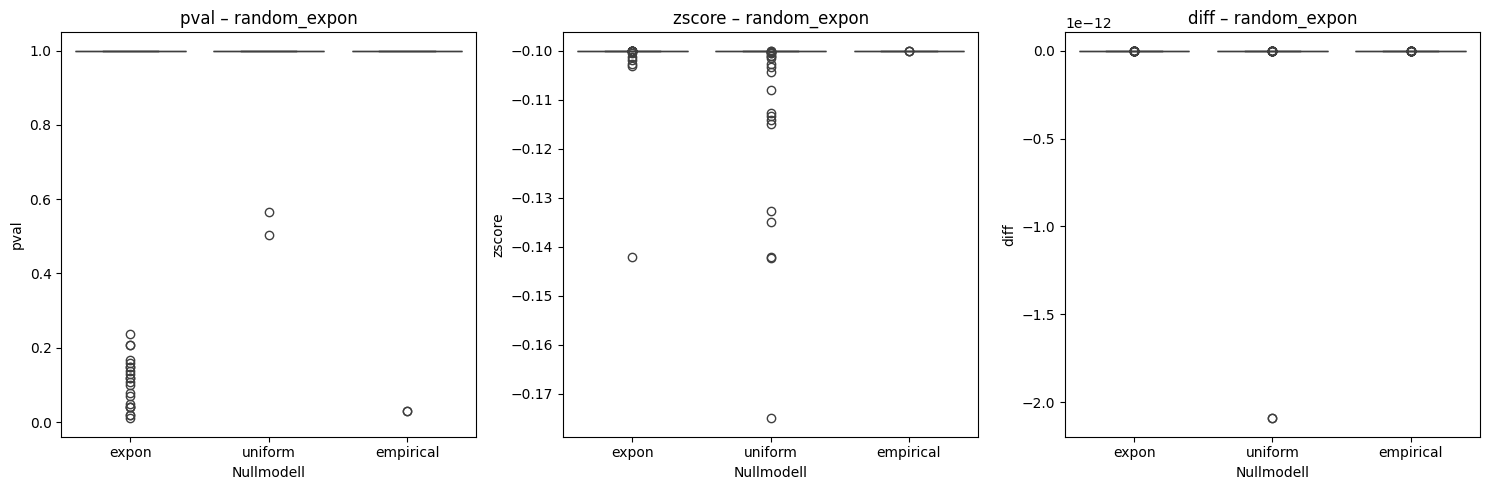

Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.


In [42]:
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ================================
# Gaussian-Proximity-Funktion
# ================================

def proximity_max_freq_gaussian(x, sharpness_base=10.0, sharpness_growth=1.0, decay=0.1,
                                max_freq=4, weight_exponent=1.0, freq_sharpness_exp=1.0,
                                neighbor_peaks=2, norm_x=1.0, output_max=1.0):
    x = np.atleast_1d(x).astype(float).ravel()
    gauss_max = np.zeros_like(x)
    freqs = np.arange(1, max_freq + 1)

    for f in freqs:
        weight = 1.0 / (f ** weight_exponent)
        k_center = np.round(x * f).astype(int)
        offsets = np.arange(-neighbor_peaks, neighbor_peaks + 1)
        k_all = k_center[:, None] + offsets[None, :]
        valid_mask = k_all > 0
        mu = k_all / f
        mu[~valid_mask] = 1.0
        sharpness = sharpness_base * (f ** freq_sharpness_exp) * (np.maximum(k_all, 1) ** sharpness_growth)
        sharpness[~valid_mask] = 1e-9
        sigma = 1.0 / (sharpness + 1e-9)
        mu_decay = np.where(valid_mask, 1.0 / (mu ** decay + 1e-9), 0.0)
        diff = x[:, None] - mu
        g = np.exp(-0.5 * (diff / sigma) ** 2) * mu_decay * weight
        gauss_max = np.maximum(gauss_max, np.max(g, axis=1))

    max_at_norm_x = np.max([1.0 / (f ** weight_exponent) for f in freqs])
    gauss_max = gauss_max / (max_at_norm_x + 1e-9) * output_max
    return gauss_max if gauss_max.shape != (1,) else gauss_max[0]

# ================================
# Pairwise-Ratios
# ================================

def pairwise_ratios(iois: np.ndarray) -> np.ndarray:
    mat = np.divide.outer(iois, iois)
    return np.maximum(mat, 1 / mat)

# ================================
# Null-Pool vorbereiten
# ================================

def generate_iopool_debug(all_iois_dict, num_sequences_pool=2000, seed=42):
    """
    Debug-Version: Nullmodelle exakt so wie die Random-Sequenzen im Test-Ordner.
    Damit sollte der Optimierer im Mittel 'scheitern' (p ≈ 0.5, diff ≈ 0, z ≈ 0).
    """
    rng = np.random.default_rng(seed)
    pool_dict = {}
    lengths_needed = sorted(set(len(iois) for iois in all_iois_dict.values()))

    for n in lengths_needed:
        # Exakt wie deine random_uniform-Sequenzen (0.1, 1.0)
        pool_uniform = rng.uniform(0.1, 1.0, size=(num_sequences_pool, n))

        # Exakt wie deine random_exponential-Sequenzen (scale=0.5, clip 0.1..2.0)
        pool_expon = rng.exponential(scale=0.5, size=(num_sequences_pool, n))
        pool_expon = np.clip(pool_expon, 0.1, 2.0)

        # Empirical = einfach nochmal aus concat ziehen (wie bei dir auch)
        all_iois_concat = np.concatenate(list(all_iois_dict.values()))
        pool_empirical = rng.choice(all_iois_concat, size=(num_sequences_pool, n), replace=True)

        pool_dict[n] = {
            "uniform": pool_uniform,
            "expon": pool_expon,
            "empirical": pool_empirical
        }
    return pool_dict

def sample_iopool(pool_dict, n, model, num_sequences, rng, replace=False):
    if n not in pool_dict:
        closest_n = min(pool_dict.keys(), key=lambda k: abs(k-n))
    else:
        closest_n = n
    pool = pool_dict[closest_n][model]
    idx = rng.choice(len(pool), size=num_sequences, replace=replace)
    return pool[idx]

# ================================
# Analyse-Funktion
# ================================

def analyze_folder(folder_path, params, pool_dict, num_sequences=200, rng=None, replace=False):
    if rng is None:
        rng = np.random.default_rng()
    results_list = []
    all_iois_dict = {}

    # IOIs laden
    seqs = []
    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue
        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue
        all_iois_dict[fname] = iois
        seqs.append((fname, iois))

    # Analyse jeder Sequenz
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = pairwise_ratios(iois)
        prox_real = proximity_max_freq_gaussian(ratios_real, **params)
        median_real = np.median(prox_real)

        row = {"filename": fname, "real_median": median_real}
        for model in ["expon", "uniform", "empirical"]:
            sampled_iois = sample_iopool(pool_dict, n, model, num_sequences, rng, replace=replace)
            medians_null = []
            for s in sampled_iois:
                ratios_null = pairwise_ratios(s)
                prox_null = proximity_max_freq_gaussian(ratios_null, **params)
                medians_null.append(np.median(prox_null))
            medians_null = np.array(medians_null)
            mean = np.mean(medians_null)
            std = np.std(medians_null, ddof=1)
            z = (median_real - mean)/std if std>0 else np.nan
            p = (np.sum(medians_null >= median_real)+1)/(len(medians_null)+1)
            row.update({
                f"{model}_mean": mean,
                f"{model}_std": std,
                f"diff_real_{model}": median_real-mean,
                f"zscore_{model}": z,
                f"pval_{model}": p
            })
        results_list.append(row)
    return pd.DataFrame(results_list), all_iois_dict

# ================================
# Bayesian Optimization
# ================================

def bayesian_search(folder_path, pool_dict, n_calls=50, num_sequences=200, seed=42,
                    objective="pval", null_model="expon", replace=False):
    default_params = {"neighbor_peaks":2, "norm_x":1.0, "output_max":1.0}
    param_space_def = {
        "sharpness_base": (1.0,50.0),
        "sharpness_growth": (0.0,5.0),
        "decay": (0.0,4.0),
        "max_freq": (1,6),
        "weight_exponent": (0.0,4.0),
        "freq_sharpness_exp": (0.0,4.0)
    }
    sk_space = [
        Real(*param_space_def["sharpness_base"], name="sharpness_base"),
        Real(*param_space_def["sharpness_growth"], name="sharpness_growth"),
        Real(*param_space_def["decay"], name="decay"),
        Integer(*param_space_def["max_freq"], name="max_freq"),
        Real(*param_space_def["weight_exponent"], name="weight_exponent"),
        Real(*param_space_def["freq_sharpness_exp"], name="freq_sharpness_exp")
    ]
    rng = np.random.default_rng(seed)
    eval_records = []
    call_counter = {"n":0}
    start_time = time.time()

    def objective_func(x):
        call_counter["n"] +=1
        elapsed = time.time()-start_time
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time*(n_calls-call_counter["n"])
        eta_min = int(remaining//60)
        eta_sec = int(remaining%60)
        print(f"[BayesOpt] Iteration {call_counter['n']}/{n_calls} (ETA {eta_min}m {eta_sec}s)")

        names = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n:v for n,v in zip(names,x)})
        params["max_freq"] = int(round(params["max_freq"]))

        df_seq, _ = analyze_folder(folder_path, params, pool_dict, num_sequences=num_sequences, rng=rng, replace=replace)
        if df_seq.empty:
            return 1e6

        col_map = {"diff":f"diff_real_{null_model}", "zscore":f"zscore_{null_model}", "pval":f"pval_{null_model}"}
        col = col_map[objective]
        vals = df_seq[col].dropna().values
        if len(vals)==0:
            return 1e5

        agg = np.median(vals)
        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})
        return -agg if objective in ("diff","zscore") else float(agg)

    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)
    summary_eval_df = pd.DataFrame(eval_records)
    agg_col_name = f"agg_{objective}_{null_model}"
    best_row = summary_eval_df.loc[summary_eval_df[agg_col_name].idxmax()] if not summary_eval_df.empty else None
    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Ergebnisse
# ================================

def optimize_and_collect(folders, n_calls=50, num_sequences=200, num_sequences_pool=2000, seed=42,
                         objective="pval", replace=False):
    all_results = []
    rng = np.random.default_rng(seed)

    for folder in folders:
        # IOIs laden
        all_iois_dict = {}
        for fname in os.listdir(folder):
            if not fname.endswith(".csv"):
                continue
            df = pd.read_csv(os.path.join(folder, fname))
            if "IOI" not in df.columns:
                continue
            iois = df["IOI"].dropna().values
            if len(iois)<3:
                continue
            all_iois_dict[fname] = iois

        pool_dict = generate_iopool(all_iois_dict, num_sequences_pool=num_sequences_pool, seed=seed)
        print(f"Folder '{folder}' geladen, {len(all_iois_dict)} Sequenzen, Null-Pool erstellt.")

        for null_model in ["expon","uniform","empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")
            summary_eval_df, best_row, res = bayesian_search(folder, pool_dict,
                                                             n_calls=n_calls,
                                                             num_sequences=num_sequences,
                                                             seed=seed,
                                                             objective=objective,
                                                             null_model=null_model,
                                                             replace=replace)
            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue
            best_params = {k: best_row[k] for k in ["sharpness_base","sharpness_growth","decay",
                                                    "max_freq","weight_exponent","freq_sharpness_exp"]}
            best_params.update({"neighbor_peaks":2,"norm_x":1.0,"output_max":1.0})
            print("Beste Parameterkombination:", best_params)

            df_seq, _ = analyze_folder(folder, best_params, pool_dict, num_sequences=num_sequences, rng=rng, replace=replace)
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                for k in ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]:
                    record[k] = best_params[k]
                all_results.append(record)
    return pd.DataFrame(all_results)

# ================================
# Boxplots
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()
    for folder in folders:
        subset = results_df[results_df["folder"]==folder]
        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics,1):
            plt.subplot(1,len(metrics),i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon"
]

seq_results_df = optimize_and_collect(folders, n_calls=30, num_sequences=100, seed=42, num_sequences_pool=5000, objective="pval", replace=True)

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("gaussian_optimization.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'gaussian_optimization.csv' gespeichert.")
